In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf 
from tensorflow import keras 

In [2]:
df = pd.read_csv(r"../../Dataset/NCA Preprocessed/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [3]:
import sys
sys.path.append("../../")
from preprocessing.data_preprocessor import DataPreprocessor


preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train.shape)


Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [4]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test_norm = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test_norm.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


In [ ]:
def jsma_regression_attack(
    model,
    x_ic,
    x_ctx,
    y,
    scaler_std,
    epsilon_physical=0.5,
    k=3,
    clip_min=-3.0,
    clip_max=3.0
):
    x_ic = tf.cast(x_ic, tf.float32)
    x_ctx = tf.cast(x_ctx, tf.float32)
    y = tf.cast(y, tf.float32)
    y = tf.reshape(y, [tf.shape(y)[0], -1])[:, :1]

    scaler_std = tf.cast(scaler_std, tf.float32)
    epsilon_physical = tf.cast(epsilon_physical, tf.float32)
    clip_min = tf.cast(clip_min, tf.float32)
    clip_max = tf.cast(clip_max, tf.float32)

    epsilon_scaled = epsilon_physical / scaler_std

    # ---- state tensors instead of Python lists ----
    x_adv = tf.Variable(x_ic)

    # boolean mask of modified features
    modified_mask = tf.zeros((20,), dtype=tf.bool)

    # candidate mask (True = available)
    candidate_mask = tf.ones((20,), dtype=tf.bool)

    # ---- original error ----
    y_pred_orig = model([x_ic, x_ctx])
    orig_error = tf.square(y - y_pred_orig)

    # ---- loop counter ----
    i0 = tf.constant(0)

    # ============================================================
    # WHILE LOOP (same stopping logic as your Python version)
    # ============================================================
    def cond(i, modified_mask, candidate_mask, x_adv):
        return tf.logical_and(
            tf.reduce_sum(tf.cast(modified_mask, tf.int32)) < k,
            tf.reduce_any(candidate_mask)
        )

    def body(i, modified_mask, candidate_mask, x_adv):

        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            y_pred = model([x_adv, x_ctx])
            loss = tf.square(y - y_pred)

        grad = tape.gradient(loss, x_adv)

        remaining = k - tf.reduce_sum(tf.cast(modified_mask, tf.int32))

        # ====================================================
        # ----------- PAIR SEARCH (same math) ----------------
        # ====================================================
        def pair_branch():
            best_saliency = tf.constant(-1e9, tf.float32)
            best_i = tf.constant(-1, tf.int32)
            best_j = tf.constant(-1, tf.int32)

            def pair_loop(i, j, best_saliency, best_i, best_j):
                cond_valid = tf.logical_and(
                    tf.logical_and(candidate_mask[i], candidate_mask[j]),
                    tf.logical_and(i < j, tf.equal(tf.sign(grad[i]), tf.sign(grad[j])))
                )

                def compute():
                    combined = tf.abs(grad[i] + grad[j])

                    limit_i = tf.where(grad[i] > 0, clip_max, clip_min)
                    limit_j = tf.where(grad[j] > 0, clip_max, clip_min)

                    room_i = tf.minimum(
                        tf.abs(limit_i - x_adv[i]) / epsilon_scaled[i], 1.0
                    )
                    room_j = tf.minimum(
                        tf.abs(limit_j - x_adv[j]) / epsilon_scaled[j], 1.0
                    )

                    sal = combined * room_i * room_j

                    better = sal > best_saliency

                    return (
                        tf.where(better, sal, best_saliency),
                        tf.where(better, i, best_i),
                        tf.where(better, j, best_j),
                    )

                return tf.cond(
                    cond_valid,
                    compute,
                    lambda: (best_saliency, best_i, best_j)
                )

            # nested loops via tf.range
            for ii in tf.range(20):
                for jj in tf.range(20):
                    best_saliency, best_i, best_j = pair_loop(
                        ii, jj, best_saliency, best_i, best_j
                    )

            def apply_pair():
                x_new = tf.tensor_scatter_nd_add(
                    x_adv,
                    [[best_i], [best_j]],
                    [
                        epsilon_scaled[best_i] * tf.sign(grad[best_i]),
                        epsilon_scaled[best_j] * tf.sign(grad[best_j]),
                    ],
                )

                new_modified = tf.tensor_scatter_nd_update(
                    modified_mask,
                    [[best_i], [best_j]],
                    [True, True],
                )

                new_candidates = tf.tensor_scatter_nd_update(
                    candidate_mask,
                    [[best_i], [best_j]],
                    [False, False],
                )

                return new_modified, new_candidates, x_new

            return tf.cond(
                best_i >= 0,
                apply_pair,
                lambda: (modified_mask, candidate_mask, x_adv)
            )

        # ====================================================
        # ----------- SINGLE FEATURE SEARCH ------------------
        # ====================================================
        def single_branch():
            masked_grad = tf.where(candidate_mask, tf.abs(grad), -1e9)

            best_i = tf.argmax(masked_grad, output_type=tf.int32)

            x_new = tf.tensor_scatter_nd_add(
                x_adv,
                [[best_i]],
                [epsilon_scaled[best_i] * tf.sign(grad[best_i])],
            )

            new_modified = tf.tensor_scatter_nd_update(
                modified_mask, [[best_i]], [True]
            )

            new_candidates = tf.tensor_scatter_nd_update(
                candidate_mask, [[best_i]], [False]
            )

            return new_modified, new_candidates, x_new

        use_pair = tf.logical_and(remaining >= 2, tf.reduce_sum(tf.cast(candidate_mask, tf.int32)) >= 2)

        modified_mask, candidate_mask, x_adv = tf.cond(
            use_pair,
            pair_branch,
            single_branch,
        )

        # ---- clip ----
        x_adv = tf.clip_by_value(x_adv, clip_min, clip_max)

        # ---- early stop ----
        current_error = tf.square(y - model([x_adv, x_ctx]))
        stop = current_error > 2.0 * orig_error

        return i + 1, modified_mask, candidate_mask, tf.cond(stop, lambda: x_adv, lambda: x_adv)

    # run loop
    _, modified_mask, _, x_adv = tf.while_loop(
        cond,
        body,
        loop_vars=[i0, modified_mask, candidate_mask, x_adv],
        maximum_iterations=k,
    )

    return x_adv, modified_mask


In [12]:
import tensorflow as tf


def targeted_rjsma_attack(
    model,
    X_ic_test,
    X_context_test,
    y_test,
    epsilon,
    k=3,
    num_steps=1,
    target_shift=0.2,
    clip_min=-3.0,
    clip_max=3.0,
    scaler_std=None,
):
    """
    Targeted Regression JSMA with VERBOSE DEBUG LOGS
    """

    x_adv = tf.identity(tf.cast(X_ic_test, tf.float32))
    ctx = tf.cast(X_context_test, tf.float32)
    y_true = tf.cast(y_test, tf.float32)

    # ----- define TARGET -----
    y_target = y_true - target_shift

    step = epsilon / num_steps

    # dtype-safe clipping
    clip_min = tf.cast(clip_min, x_adv.dtype)
    clip_max = tf.cast(clip_max, x_adv.dtype)

    tf.print("\n[JSMA] Starting attack")
    tf.print("[JSMA] epsilon =", epsilon, ", steps =", num_steps, ", k =", k)

    for i in tf.range(num_steps):

        # ---- targeted loss gradient ----
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            pred = model([x_adv, ctx], training=False)
            loss = tf.reduce_mean(tf.square(pred - y_target))

        grads = tape.gradient(loss, x_adv)

        # ---- DEBUG: gradient magnitude ----
        grad_mean = tf.reduce_mean(tf.abs(grads))
        tf.print("[JSMA] step", i, "| mean(|grad|) =", grad_mean)

        if grads is None:
            tf.print("[JSMA] gradients are None → stopping")
            break

        # ---- normalize gradient ----
        grad_norm = tf.reduce_mean(tf.abs(grads), axis=[1, 2], keepdims=True) + 1e-8
        grads_scaled = grads / grad_norm

        # ---- saliency ----
        saliency = tf.abs(grads_scaled)[:, :, 0]

        # ---- top-k indices ----
        topk = tf.math.top_k(saliency, k=k)
        idx = topk.indices

        perturb = tf.zeros_like(x_adv)

        # sparse update
        for b in range(x_adv.shape[0]):
            for j in idx[b]:
                perturb = tf.tensor_scatter_nd_add(
                    perturb,
                    indices=[[b, j, 0]],
                    updates=[step * grads_scaled[b, j, 0]],
                )

        # ---- DEBUG: perturb size ----
        pert_mean = tf.reduce_mean(tf.abs(perturb))
        tf.print("[JSMA] step", i, "| mean(|perturb|) =", pert_mean)

        # ---- apply + clip ----
        x_adv = tf.clip_by_value(x_adv + perturb, clip_min, clip_max)

        # ---- DEBUG: prediction movement toward target ----
        new_pred = model([x_adv, ctx], training=False)
        shift = tf.reduce_mean(tf.abs(new_pred - y_target))
        tf.print("[JSMA] step", i, "| mean distance to target =", shift)

    tf.print("[JSMA] Attack finished\n")

    return x_adv


In [17]:
import tensorflow as tf


@tf.function
def fast_jsma_regression_batch(
    model,
    x_ic,                 # (B, 20)
    x_ctx,                # (B, ctx_dim) or None
    sigma_ic,             # (20,)
    delta_real=0.02,
    max_pairs=2,
    increase=True,
    clip_min=-3.0,
    clip_max=3.0,
):
    """
    GPU-vectorized pair-wise regression JSMA.
    Returns adversarial IC batch and final SOH predictions.
    """

    B = tf.shape(x_ic)[0]
    n = tf.shape(x_ic)[1]

    x_adv = tf.Variable(x_ic, dtype=tf.float32)

    # -------- feature-wise scaled epsilon --------
    eps_scaled = delta_real / sigma_ic            # (20,)
    eps_scaled = tf.reshape(eps_scaled, (1, n))   # (1, 20)
    eps_scaled = tf.tile(eps_scaled, [B, 1])      # (B, 20)

    # -------- modified feature mask --------
    modified = tf.zeros((B, n), dtype=tf.bool)

    direction = 1.0 if increase else -1.0
    extreme = -1e9 if increase else 1e9

    # ================= ITERATIVE PAIR LOOP =================
    for _ in tf.range(max_pairs):

        # ----- gradient computation -----
        with tf.GradientTape() as tape:
            tape.watch(x_adv)

            if x_ctx is None:
                y_pred = model(x_adv, training=False)        # (B, 1)
            else:
                y_pred = model([x_adv, x_ctx], training=False)

        grad = tape.gradient(y_pred, x_adv)                  # (B, 20)

        # ----- sign constraint -----
        valid_sign = grad > 0 if increase else grad < 0       # (B, 20)

        # ----- pair saliency via broadcasting -----
        g_i = tf.expand_dims(grad, 2)                         # (B, 20, 1)
        g_j = tf.expand_dims(grad, 1)                         # (B, 1, 20)
        saliency = g_i + g_j                                  # (B, 20, 20)

        # ----- build masks -----

        # diagonal mask
        diag = tf.eye(n, batch_shape=[B], dtype=tf.bool)

        # modified feature mask
        mod_i = tf.expand_dims(modified, 2)
        mod_j = tf.expand_dims(modified, 1)

        # wrong sign mask
        sign_i = tf.expand_dims(tf.logical_not(valid_sign), 2)
        sign_j = tf.expand_dims(tf.logical_not(valid_sign), 1)

        invalid = diag | mod_i | mod_j | sign_i | sign_j

        # apply extreme masking
        saliency = tf.where(invalid, extreme, saliency)

        # ----- find best pair per sample -----
        flat = tf.reshape(saliency, (B, -1))                  # (B, 400)

        best_idx = (
            tf.argmax(flat, axis=1)
            if increase
            else tf.argmin(flat, axis=1)
        )                                                     # (B,)

        i = best_idx // n                                     # (B,)
        j = best_idx % n                                      # (B,)

        # ----- gather epsilon updates -----
        eps_i = tf.gather(eps_scaled, i, batch_dims=1)        # (B,)
        eps_j = tf.gather(eps_scaled, j, batch_dims=1)        # (B,)

        # ----- apply perturbations -----
        updates_i = direction * eps_i
        updates_j = direction * eps_j

        scatter_i = tf.stack([tf.range(B), i], axis=1)
        scatter_j = tf.stack([tf.range(B), j], axis=1)

        x_adv.assign(
            tf.tensor_scatter_nd_add(x_adv, scatter_i, updates_i)
        )
        x_adv.assign(
            tf.tensor_scatter_nd_add(x_adv, scatter_j, updates_j)
        )

        # ----- clip -----
        x_adv.assign(tf.clip_by_value(x_adv, clip_min, clip_max))

        # ----- update modified mask -----
        modified = tf.tensor_scatter_nd_update(
            modified, scatter_i, tf.ones(B, dtype=tf.bool)
        )
        modified = tf.tensor_scatter_nd_update(
            modified, scatter_j, tf.ones(B, dtype=tf.bool)
        )

    # ================= FINAL PREDICTION =================
    if x_ctx is None:
        final_pred = model(x_adv, training=False)
    else:
        final_pred = model([x_adv, x_ctx], training=False)

    return x_adv, final_pred


In [8]:
def attack_eval(
    model,
    X_ic_test,
    X_context_test,
    y_test_norm,
    y_std,
    y_mean,
    epsilon,
    attack_fn,
    clip_min,
    clip_max,
    scaler_std,
    model_name="",
    plot=True,
    **attack_kwargs,   # ← allows FGSM/PGD/JSMA params
):
    """
    Evaluates a model under adversarial attack.
    Returns real-scale SOH metrics.
    """

    # ---------- Clean prediction (normalized) ----------
    y_pred_norm = model.predict([X_ic_test, X_context_test], verbose=0).flatten()

    # ---------- Generate adversarial samples ----------
    X_ic_test_adv = attack_fn(
        model=model,
        X_ic_test=X_ic_test,
        X_context_test=X_context_test,
        y_test=y_test_norm,
        epsilon=epsilon,
        scaler_std=scaler_std,
        clip_min=clip_min,
        clip_max=clip_max,
        **attack_kwargs
    )

    # ---------- Adversarial prediction ----------
    y_pred_adv_norm = model.predict([X_ic_test_adv, X_context_test], verbose=0).flatten()

    # ---------- Inverse scaling to REAL SOH ----------
    y_true_real = y_test_norm * y_std + y_mean
    y_pred_real = y_pred_norm * y_std + y_mean
    y_pred_adv_real = y_pred_adv_norm * y_std + y_mean

    # ---------- Metrics ----------
    mae_clean = mean_absolute_error(y_true_real, y_pred_real)
    mae_adv = mean_absolute_error(y_true_real, y_pred_adv_real)
    delta_mae = mae_adv - mae_clean

    mape_clean = mean_absolute_percentage_error(y_true_real, y_pred_real)
    mape_adv = mean_absolute_percentage_error(y_true_real, y_pred_adv_real)

    # ---------- Optional plots ----------
    if plot:
        plt.figure(figsize=(16, 6))

        min_val = min(y_true_real.min(), y_pred_real.min())
        max_val = max(y_true_real.max(), y_pred_real.max())

        # Clean
        plt.subplot(1, 2, 1)
        plt.scatter(y_true_real, y_pred_real, alpha=0.5)
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.title(f"{model_name} – Clean")
        plt.xlabel("True SOH")
        plt.ylabel("Predicted SOH")
        plt.grid()

        # Attacked
        plt.subplot(1, 2, 2)
        plt.scatter(y_true_real, y_pred_adv_real, alpha=0.5)
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.title(f"{model_name} – Attacked (ε={epsilon})")
        plt.xlabel("True SOH")
        plt.ylabel("Predicted SOH")
        plt.grid()

        plt.show()

    return {
        "MAE_clean": mae_clean,
        "MAE_adv": mae_adv,
        "ΔMAE": delta_mae,
        "MAPE_clean": mape_clean,
        "MAPE_adv": mape_adv,
    }


In [6]:
from tabulate import tabulate

def run_attack_evaluation(
    model,
    model_name,
    attack_fn,
    X_ic_test,
    X_context_test,
    y_test_norm,
    y_std,
    y_mean,
    eps_values,
    clip_min,
    clip_max,
    scaler_std,
    plot=False,
    **attack_kwargs,
):
    """
    Runs adversarial evaluation across epsilon values
    and prints a formatted table.
    """

    results = []

    for eps in eps_values:
        res = attack_eval(
            model=model,
            X_ic_test=X_ic_test,
            X_context_test=X_context_test,
            y_test_norm=y_test_norm,
            y_std=y_std,
            y_mean=y_mean,
            epsilon=eps,
            attack_fn=attack_fn,
            model_name=model_name,
            clip_min=clip_min,
            clip_max=clip_max,
            scaler_std=scaler_std,
            plot=plot,
            **attack_kwargs,
        )

        results.append([
            eps,
            res["MAE_clean"],
            res["MAE_adv"],
            res["ΔMAE"],
            res["MAPE_clean"],
            res["MAPE_adv"],
        ])

    headers = [
        "Epsilon",
        "MAE (Clean)",
        "MAE (Attacked)",
        "ΔMAE",
        "MAPE (Clean)",
        "MAPE (Attacked)",
    ]

    print(f"\nAdversarial Evaluation Results – {model_name}")
    print(tabulate(results, headers=headers, floatfmt=".4f"))

    return results


In [9]:
from tqdm import tqdm 

batch_size = 32

# Identify the extreme sample
extreme_idx = np.where(X_ic_test > 5.0)[0]
print(f"Extreme sample indices: {extreme_idx}")

# Remove or cap extreme samples for adversarial testing
X_ic_test_clean = X_ic_test.copy()
X_ic_test_clean[extreme_idx] = np.percentile(X_ic_train,99)  # Cap at max

y_train_tf = y_train.reshape(-1,1).astype(np.float32)
y_test_tf = y_test_norm.reshape(-1,1).astype(np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_ic_train.astype(np.float32),X_context_train.astype(np.float32),
     y_train_tf)).shuffle(buffer_size=len(X_ic_train)).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_ic_test_clean.astype(np.float32), X_context_test.astype(np.float32),
    y_test_tf)).batch(batch_size)

Extreme sample indices: [583 583 583 583 583 583 583 583]


In [10]:
clip_min = np.percentile(X_ic_train, 0.5)
clip_max = np.percentile(X_ic_train, 99.5)

In [15]:
def run_targeted_jsma_experiments(
    model,
    model_name,
    attack_fn,
    X_ic_test,
    X_context_test,
    y_test_norm,
    y_std,
    y_mean,
    eps_values,
    target_shifts,
    num_steps_list,
    clip_min,
    clip_max,
    scaler_std,
):
    """
    Runs targeted JSMA experiments across:
        • multiple target shifts
        • multiple JSMA steps
        • epsilon sweep

    Prints separate tables for each configuration.
    """

    all_results = {}

    for shift in target_shifts:
        for steps in num_steps_list:

            print("\n" + "=" * 60)
            print(f"{model_name} | Target shift = {shift} | Steps = {steps}")
            print("=" * 60)

            results = run_attack_evaluation(
                model=model,
                model_name=f"{model_name} | Δ={shift} | T={steps}",
                attack_fn=attack_fn,
                X_ic_test=X_ic_test,
                X_context_test=X_context_test,
                y_test_norm=y_test_norm,
                y_std=y_std,
                y_mean=y_mean,
                eps_values=eps_values,
                clip_min=clip_min,
                clip_max=clip_max,
                scaler_std=scaler_std,
                plot=False,
                k=3,
                target_shift=shift,
                num_steps=steps,
            )

            all_results[(shift, steps)] = results

    return all_results


In [16]:
cnn_lstm = keras.models.load_model(r"../../Models/CNN_LSTM_NT.keras") 

print("--------")
print("CNN+LSTM")
print("--------")

k_values = [1, 2, 3, 4, 5, ]
'''run_attack_evaluation(
    model=cnn_lstm,
    model_name="CNN+LSTM",
    attack_fn=jsma_attack,
    X_ic_test=X_ic_test_clean,
    X_context_test=X_context_test,
    y_test_norm=y_test_tf,
    y_std=y_std,
    y_mean=y_mean,
    eps_values=k_values,
    clip_min=clip_min,
    clip_max=clip_max,
    scaler_std=preprocessor.ic_scaler.scale_,
    plot=True
)
'''
eps_values = [0.5, 1, 2, 3, 5]

target_shifts = [0.05, 0.10, 0.15, 0.20]   # realistic SOH deception
num_steps_list = [1, 5, 10, 20]             # JSMA strength levels

results = run_targeted_jsma_experiments(
    model=cnn_lstm,
    model_name="CNN-LSTM",
    attack_fn=targeted_rjsma_attack,
    X_ic_test=X_ic_test,
    X_context_test=X_context_test,
    y_test_norm=y_test_tf,
    y_std=y_std,
    y_mean=y_mean,
    eps_values=eps_values,
    target_shifts=target_shifts,
    num_steps_list=num_steps_list,
    clip_min=clip_min,
    clip_max=clip_max,
    scaler_std=preprocessor.ic_scaler.scale_,
    plot=True,
)



--------
CNN+LSTM
--------

CNN-LSTM | Target shift = 0.05 | Steps = 1

[JSMA] Starting attack
[JSMA] epsilon = 0.5 , steps = 1 , k = 3
[JSMA] step 0 | mean(|grad|) = 1.38919825e-06
[JSMA] step 0 | mean(|perturb|) = 0.205530688
[JSMA] step 0 | mean distance to target = 0.52197665
[JSMA] Attack finished


[JSMA] Starting attack
[JSMA] epsilon = 1 , steps = 1 , k = 3
[JSMA] step 0 | mean(|grad|) = 1.38919825e-06
[JSMA] step 0 | mean(|perturb|) = 0.411061376
[JSMA] step 0 | mean distance to target = 0.711042523
[JSMA] Attack finished


[JSMA] Starting attack
[JSMA] epsilon = 2 , steps = 1 , k = 3
[JSMA] step 0 | mean(|grad|) = 1.38919825e-06
[JSMA] step 0 | mean(|perturb|) = 0.822122753
[JSMA] step 0 | mean distance to target = 0.771207392
[JSMA] Attack finished


[JSMA] Starting attack
[JSMA] epsilon = 3 , steps = 1 , k = 3
[JSMA] step 0 | mean(|grad|) = 1.38919825e-06
[JSMA] step 0 | mean(|perturb|) = 1.2331841
[JSMA] step 0 | mean distance to target = 0.772980928
[JSMA] Attack finished

KeyboardInterrupt: 

In [50]:
with tf.GradientTape() as tape:
    x = tf.cast(X_ic_test[:32], tf.float32)
    ctx = tf.cast(X_context_test[:32], tf.float32)
    y = tf.cast(y_test_tf[:32], tf.float32)

    tape.watch(x)
    pred = cnn_lstm([x, ctx], training=False)
    loss = tf.reduce_mean(tf.square(y - pred))

grads = tape.gradient(loss, x)

print("Gradient abs mean:", tf.reduce_mean(tf.abs(grads)).numpy())


Gradient abs mean: 0.000113970134


In [ ]:
print("---------")
print("CNN + GRU")
print("---------")

cnn_gru = keras.models.load_model(r"F:\College\SEM 8\Project Phase 2\Models\best_cnn_gru.keras")
attack_eval(cnn_gru, X_ic_test, X_context_test, y_test, epsilon=0.7, k=3, model_name="CNN+GRU")

---------
CNN + GRU
---------


ValueError: File not found: filepath=F:\College\SEM 8\Project Phase 2\Models\best_cnn_gru.keras. Please ensure the file is an accessible `.keras` zip file.

---
RCN
---
-----------------
Normal Conditions
-----------------
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
R2 Score: 0.9963593762223153
MAE: 0.04451132274039512
MSE: 0.0035955973433850785
MAPE: 0.47440765388510436
--------------------------
C and W attack performance
--------------------------
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R2 Score: 0.7567894568382224
MAE: 0.4040242882903583
MSE: 0.24020256864659245
MAPE: 0.47440765388510436
-----
PLOTS
-----


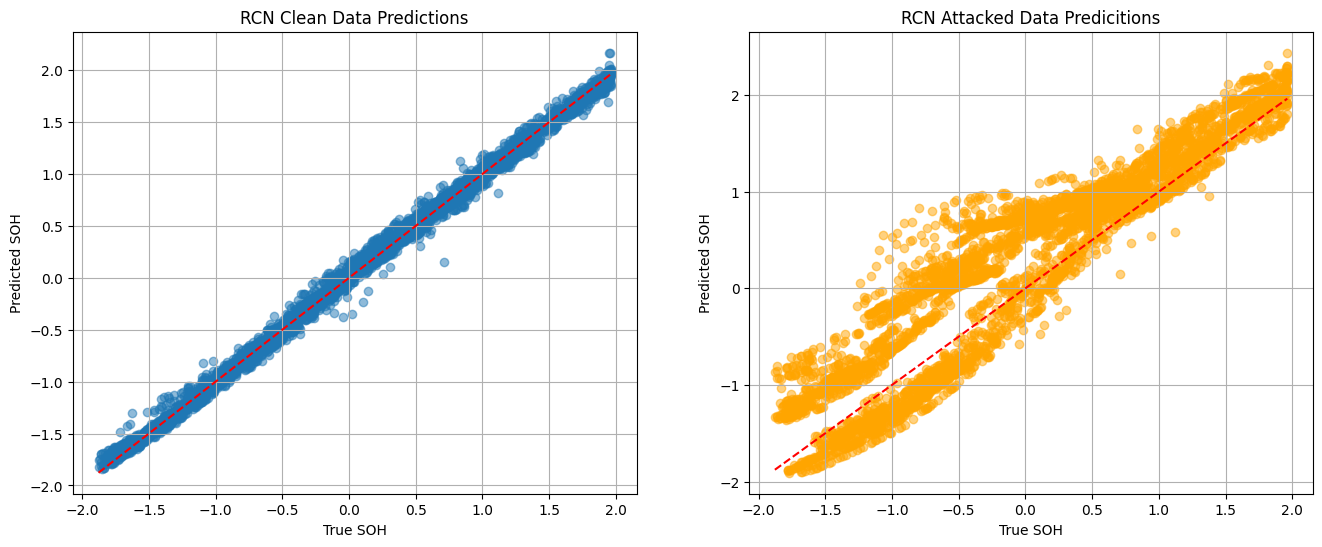

In [ ]:
rcn = keras.models.load_model(r"F:\College\SEM 8\Project Phase 2\Models\best_rcn.keras")

print("---")
print("RCN")
print("---")

attack_eval(rcn, X_ic_test, X_context_test, y_test, epsilon=0.7, k=3, model_name="RCN")

---
CNN
---
-----------------
Normal Conditions
-----------------
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
R2 Score: 0.9848092259048676
MAE: 0.09442292512359997
MSE: 0.015002897941615016
MAPE: 0.5742935546369837
--------------------------
C and W attack performance
--------------------------
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
R2 Score: 0.46490054265216463
MAE: 0.6173379118146561
MSE: 0.5284814649291389
MAPE: 0.5742935546369837
-----
PLOTS
-----


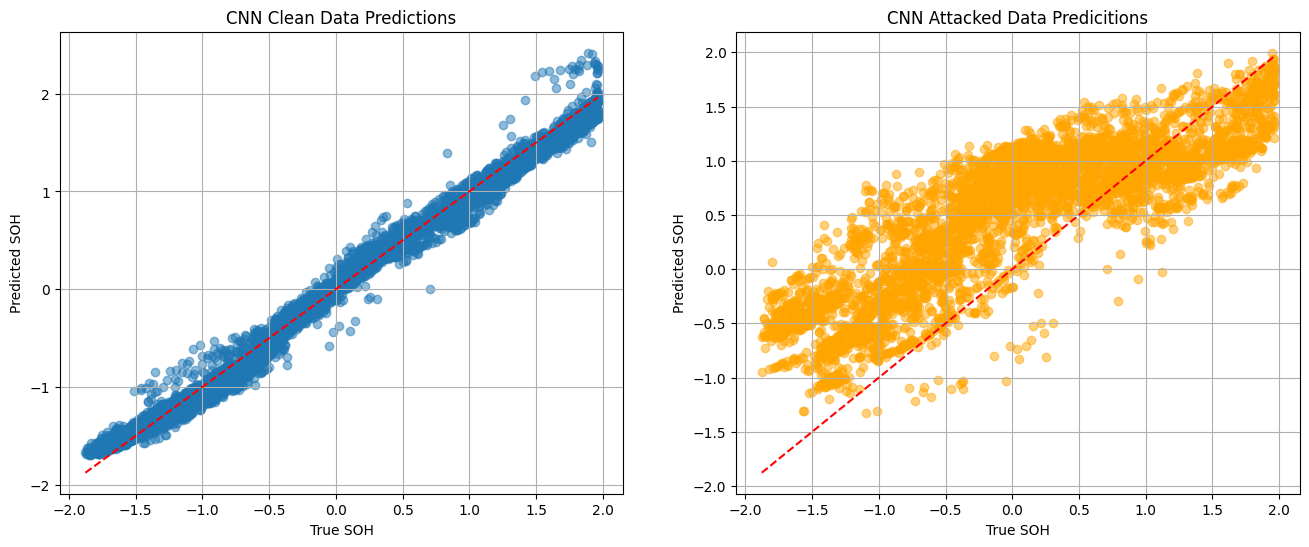

In [ ]:
print("---")
print("CNN")
print("---")

cnn = keras.models.load_model(r"F:\College\SEM 8\Project Phase 2\Models\best_cnn.keras")

attack_eval(cnn, X_ic_test, X_context_test, y_test, epsilon=0.7, k=3, model_name="CNN")

In [ ]:
idx = 100   

orig_ic = X_ic_test[idx].reshape(-1)     
orig_ctx = X_context_test[idx].reshape(1,-1)
orig_true = y_test[idx]

adv_ic = jsma_attack(
    cnn_gru,
    X_ic_test[idx:idx+1],     
    X_context_test[idx:idx+1],
    y_test[idx:idx+1]
)

adv_ic = adv_ic.reshape(-1)

y_pred_orig = cnn_gru.predict([X_ic_test[idx:idx+1], X_context_test[idx:idx+1]])[0][0]
y_pred_adv  = cnn_gru.predict([adv_ic.reshape(1,-1,1), X_context_test[idx:idx+1]])[0][0]

y_pred_orig = y_pred_orig * y_std + y_mean
y_pred_adv = y_pred_adv * y_std + y_mean

orig_true = orig_true * y_std + y_mean

print("Original pred:", y_pred_orig)
print("Adversarial pred:", y_pred_adv)
print("True value:", orig_true)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Original pred: -0.18219501
Adversarial pred: 0.77730423
True value: -0.2225499516940588


Original prediction : 86.02744617771049
Adversarial prediction : 84.17363995253069
True SOH : [86.45000001]


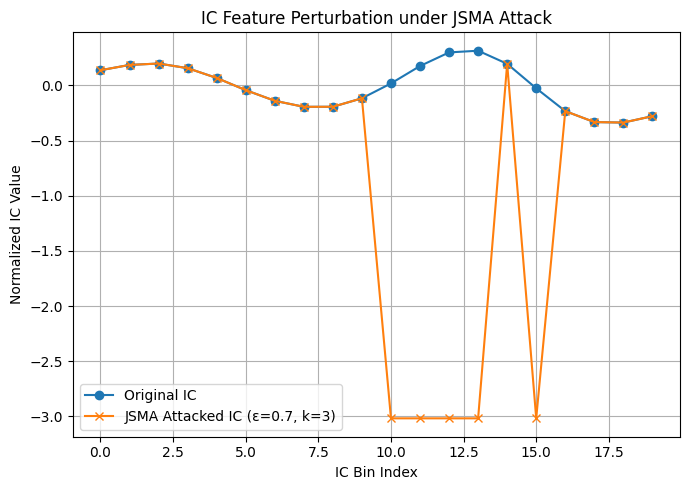

In [34]:
idx = 100

# ----------- Select one sample -----------
x_ic_sample = X_ic_test[idx:idx+1]        # (1, T, 1)
x_ctx_sample = X_context_test[idx:idx+1]  # (1, C)
y_true_norm_sample = y_test_tf[idx:idx+1] # normalized SOH

orig_ic = x_ic_sample.reshape(-1)

# ----------- Generate adversarial IC -----------
adv_ic_tensor = jsma_attack(
    model=cnn_lstm,
    X_ic_test=x_ic_sample,
    X_context_test=x_ctx_sample,
    y_test=y_true_norm_sample,
    epsilon=2.5,
    k=5,
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
)

adv_ic = adv_ic_tensor.numpy().reshape(-1)

# ----------- Predictions (normalized) -----------
y_pred_orig_norm = cnn_lstm.predict([x_ic_sample, x_ctx_sample], verbose=0)[0][0]
y_pred_adv_norm  = cnn_lstm.predict(
    [adv_ic.reshape(1, -1, 1), x_ctx_sample],
    verbose=0
)[0][0]

# ----------- Convert to REAL SOH -----------
y_pred_orig = y_pred_orig_norm * y_std + y_mean
y_pred_adv  = y_pred_adv_norm * y_std + y_mean
y_true_real = y_true_norm_sample[0] * y_std + y_mean

print("Original prediction :", y_pred_orig)
print("Adversarial prediction :", y_pred_adv)
print("True SOH :", y_true_real)

# ----------- Plot IC distortion -----------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(orig_ic, marker="o", label="Original IC")
plt.plot(adv_ic, marker="x", label="JSMA Attacked IC (ε=0.7, k=3)")

plt.title("IC Feature Perturbation under JSMA Attack")
plt.xlabel("IC Bin Index")
plt.ylabel("Normalized IC Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


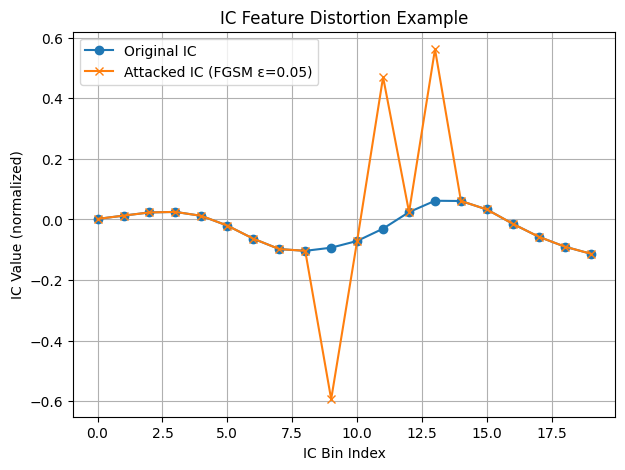

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(orig_ic, marker='o', label="Original IC")
plt.plot(adv_ic, marker='x', label="Attacked IC (JSMA ε=0.7, no.of samples attacked = 3)")
plt.title("IC Feature Distortion Example")
plt.xlabel("IC Bin Index")
plt.ylabel("IC Value (normalized)")
plt.legend()
plt.grid(True)
plt.show()
